# <span style="color:green">Prof. Glen Nwaila and Dr. Steven Zhang
</span>

# <span style="color:blue">Practical 1: Relational Geospatial Data
</span>

### Load Packages

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Relational Data

In [57]:
# Let's load a dataset
df1 = pd.read_excel('Chem Data/Strange_Lake_OLD.xlsx')
df1

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Zn,Cu,Pb,Ni,Co,Ag,Mn,Fe,As,Mo,F,LOI,Hg,U
0,013L781002,013L,54.989093,-62.019071,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,23,40,0.3
1,013L781003,013L,54.975382,-62.030577,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,33,70,0.5
2,013L781004,013L,54.976331,-62.044913,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,27.2,50,0.6
3,013L781005,013L,54.973541,-62.054790,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,29.6,40,0.6
4,013L781007,013L,54.936983,-62.026399,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,33.6,60,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,023J783278,023J,54.483518,-66.172597,192,68,8,58,24,0.4,670,5.90,10,2,490,13.4,290,6.2
3437,023J783279,023J,54.482485,-66.128816,132,32,3,28,6,0.4,510,3.10,3,3,280,25.2,180,2.5
3438,023J783282,023J,54.483288,-66.094340,138,34,6,36,13,<0.2,300,3.30,4,<2,440,12.6,150,3.7
3439,023J783283,023J,54.471281,-66.048911,168,46,6,25,7,<0.2,200,1.45,9,<2,110,45.8,160,1.3


In [58]:
# What are the column names? What do they mean?
# Let's check them

df1['Unique ID'].describe()

count           3441
unique          3441
top       013L781002
freq               1
Name: Unique ID, dtype: object

In [59]:
# Notice that the "count" equals "unique"? That means this column contains information that is unique to each entry.
# What about other columns?

df1.describe()

,Latitude_NAD83,Longitude_NAD83,Zn,Cu,Mn,Fe,Hg
count,3441.000000,3441.000000,3441.000000,3441.000000,3441.000000,3441.000000,3441.000000
mean,55.383663,-63.778378,111.829119,28.005522,662.333333,2.686199,77.119442
std,0.853529,1.451083,104.297344,23.771434,3055.596946,2.569613,53.934478
min,54.005243,-66.997815,14.000000,2.000000,10.000000,0.100000,10.000000
25%,54.646363,-64.884206,62.000000,14.000000,95.000000,1.100000,40.000000
50%,55.238594,-63.316447,90.000000,22.000000,160.000000,1.800000,60.000000
75%,56.136332,-62.667055,132.000000,34.000000,350.000000,3.300000,90.000000
max,56.997959,-62.001419,2800.000000,355.000000,99999.000000,25.000000,840.000000


In [60]:
# Notice that not all columns were described. Some of the columns contain only non-numerical entries. 
# Hence no statistics could be derived from them.

df1['NTS Sheet'].describe()

count     3441
unique       5
top       014D
freq      1001
Name: NTS Sheet, dtype: object

In [61]:
# Let's infer what the columns mean. By the way, column names is a form of "metadata" - data that describes other data.
df1.columns

Index(['Unique ID', 'NTS Sheet', 'Latitude_NAD83', 'Longitude_NAD83', 'Zn',
       'Cu', 'Pb', 'Ni', 'Co', 'Ag', 'Mn', 'Fe', 'As', 'Mo', 'F', 'LOI', 'Hg',
       'U'],
      dtype='object')

In [ ]:
# Looks like "Unique ID" is what it says it is. 
# "NTS Sheet" seems to not be unique for every entry but there are a total of 5 unique types of it.
# "Latitude_NAD83" and "Longitude_NAD83" seem to be the coordinates coded in the NAD83 datum.
# Other things like "Zn" are chemical element abbreviations according to the periodic table.
# "LOI" is loss on ignition.
# So this is a survey geochemical dataset.

In [ ]:
# "Unique ID" appears to be a primary key. 
# "NTS Sheet" appears to be a secondary key.
# Everything else appears to be attributes.
# Each row seems to be an observation.

In [ ]:
# Why are primary keys important?


In [62]:
# Let's load a new dataset - from a reanalysis of the same samples a few decades later (2016)
df2 = pd.read_excel('Chem Data/Strange_Lake_NEW.xlsx')
df2

,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),Ag,Al,As,Au,B,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,NaN,NaN,NaN,NaN,NaN,PPB,%,PPM,PPB,PPM,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM
1,013L781002,Routine,013L,54.98900,-62.01995,57,2.89,<0.1,1,<20,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,013L781003,Routine,013L,54.97529,-62.03145,106,3.22,0.1,1.6,<20,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,013L781004,Routine,013L,54.97623,-62.04579,59,2.34,0.1,1.1,<20,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,013L781005,First Field Duplicate,013L,54.97344,-62.05566,70,2.26,0.1,0.9,<20,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3437,023J783278,Routine,023J,54.48340,-66.17335,822,2.46,11.9,1.5,<20,...,0.037,0.21,0.32,5.4,51,<0.1,23.4,1.87,245.6,7.3
3438,023J783279,Routine,023J,54.48237,-66.12957,559,1.39,4.8,1.6,<20,...,0.022,0.09,0.18,1.9,25,<0.1,12.76,1.01,140.3,6
3439,023J783282,Routine,023J,54.48317,-66.09509,194,1.38,5.5,1.3,<20,...,0.049,0.13,0.13,2.3,38,<0.1,9.84,0.87,135.4,10.9
3440,023J783283,Routine,023J,54.47116,-66.04967,264,0.69,11.4,1.2,<20,...,0.009,0.08,0.16,1.6,10,<0.1,14.21,1.07,179.3,2.6


In [63]:
# Notice that the primary key = "Unique ID" is also present - which makes sense because the samples haven't changed.

df2['Unique ID'].describe()

count           3441
unique          3441
top       013L781002
freq               1
Name: Unique ID, dtype: object

In [ ]:
# Let's use some math to figure out what's different between the two sets of data
# What is a "set"?


In [64]:
# Let's see some properties of the "set"
x1 = [1,1,2,2,3,4,5]
x2 = [2,3,3,4,5,6,6]


In [65]:
set(x1)

{1, 2, 3, 4, 5}

In [66]:
set(x2)

{2, 3, 4, 5, 6}

In [67]:
set(x1).union(set(x2))

{1, 2, 3, 4, 5, 6}

In [68]:
set(x1).intersection(set(x2))

{2, 3, 4, 5}

In [69]:
set(x1).symmetric_difference(set(x2))

{1, 6}

In [70]:
set(x1)-set(x2)

{1}

In [71]:
set(x2)-set(x1)

{6}

In [72]:
#There are other properties of sets that are interesting and comes in handy, but for now, let's focus on its application.
set(df2['Unique ID']).symmetric_difference(set(df1['Unique ID']))

{nan}

In [ ]:
# This means that a single entry "nan", which stands for "not a number" is different in the primary key column between the two.



In [73]:
# There are some built-in functions in Pandas that would also do something similar
df1['Unique ID'].nunique(), df2['Unique ID'].nunique()

(3441, 3441)

In [74]:
df1['Unique ID'].unique()

array(['013L781002', '013L781003', '013L781004', ..., '023J783282',
       '023J783283', '023J783284'], dtype=object)

In [75]:
df2['Unique ID'].unique()

array([nan, '013L781002', '013L781003', ..., '023J783282', '023J783283',
       '023J783284'], dtype=object)

In [78]:
[i**2 for i in range(10)]

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

In [79]:
df1_diff_df2 = [element for element in df1['Unique ID'].unique() if element not in df2['Unique ID'].unique()]
df2_diff_df1 = [element for element in df2['Unique ID'].unique() if element not in df1['Unique ID'].unique()]

In [80]:
for element in df2['Unique ID'].unique():
    if element not in df1['Unique ID'].unique():
        print(element)

nan


In [81]:
df1_diff_df2 + df2_diff_df1

[nan]

In [ ]:
# There are generally many ways to accomplish a same task - fundamental to much of programming
# How do we choose a better method?


In [82]:
%%time

# We can use the Jupyter notebook's built-in magic command to time a cell
for i in range(10):
    set(df2['Unique ID']).symmetric_difference(set(df1['Unique ID']))

Wall time: 7 ms


In [83]:
%%time 

# Ditto for the other method
for i in range(10):
    df1_diff_df2 = [element for element in df1['Unique ID'].unique() if element not in df2['Unique ID'].unique()]
    df2_diff_df1 = [element for element in df2['Unique ID'].unique() if element not in df1['Unique ID'].unique()]
    df1_diff_df2 + df2_diff_df1

Wall time: 16.5 s


In [84]:
# But those methods don't let us capture the exact time in a variable for better analysis.
# We can do that with the time library.
# Let's calculate how fast each method is - first, let's import the library we need.

import time


In [85]:
# Now let's time the first method using "set".
start_time = time.time()

for i in range(10):
    set(df2['Unique ID']).symmetric_difference(set(df1['Unique ID']))

time_method1 = time.time() - start_time
print(time_method1, "seconds")


0.008108854293823242 seconds


In [86]:
# Let's do the same for the second method using two loops and list comprehension.
start_time = time.time()

for i in range(10):
    df1_diff_df2 = [element for element in df1['Unique ID'].unique() if element not in df2['Unique ID'].unique()]
    df2_diff_df1 = [element for element in df2['Unique ID'].unique() if element not in df1['Unique ID'].unique()]
    df1_diff_df2 + df2_diff_df1
    
time_method2 = time.time() - start_time
print(time_method2, "seconds")


15.348058938980103 seconds


In [87]:
# Now we can calculate the speed up factor for the "set" method relative to the loop method.
speed_up_factor = time_method2/time_method1
speed_up_factor

1892.7530798859193

In [88]:
# Okay, now let's get back to manipulating datasets and see why primary key is important.
df1.merge(df2, on = 'Unique ID', how = 'right')

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Zn_x,Cu_x,Pb_x,Ni_x,Co_x,Ag_x,...,Ti,Tl,Tm,U_y,V,W,Y,Yb,Zn_y,Zr
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM
1,013L781002,013L,54.989093,-62.019071,40.0,38.0,<2,43,10,<0.2,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,013L781003,013L,54.975382,-62.030577,40.0,44.0,<2,35,8,<0.2,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,013L781004,013L,54.976331,-62.044913,46.0,30.0,<2,34,8,<0.2,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,013L781005,013L,54.973541,-62.054790,50.0,26.0,<2,22,6,<0.2,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3437,023J783278,023J,54.483518,-66.172597,192.0,68.0,8,58,24,0.4,...,0.037,0.21,0.32,5.4,51,<0.1,23.4,1.87,245.6,7.3
3438,023J783279,023J,54.482485,-66.128816,132.0,32.0,3,28,6,0.4,...,0.022,0.09,0.18,1.9,25,<0.1,12.76,1.01,140.3,6
3439,023J783282,023J,54.483288,-66.094340,138.0,34.0,6,36,13,<0.2,...,0.049,0.13,0.13,2.3,38,<0.1,9.84,0.87,135.4,10.9
3440,023J783283,023J,54.471281,-66.048911,168.0,46.0,6,25,7,<0.2,...,0.009,0.08,0.16,1.6,10,<0.1,14.21,1.07,179.3,2.6


In [89]:
# Let's do something about the auto-renamed column names

elem_df = pd.read_csv('Chem Data/Periodic Table of Elements.csv')
elem_df

,AtomicNumber,Element,Symbol,AtomicMass,NumberofNeutrons,NumberofProtons,NumberofElectrons,Period,Group,Phase,...,FirstIonization,Density,MeltingPoint,BoilingPoint,NumberOfIsotopes,Discoverer,Year,SpecificHeat,NumberofShells,NumberofValence
0,1,Hydrogen,H,1.007,0,1,1,1,1.0,gas,...,13.5984,0.000090,14.175,20.28,3.0,Cavendish,1766.0,14.304,1,1.0
1,2,Helium,He,4.002,2,2,2,1,18.0,gas,...,24.5874,0.000179,NaN,4.22,5.0,Janssen,1868.0,5.193,1,NaN
2,3,Lithium,Li,6.941,4,3,3,2,1.0,solid,...,5.3917,0.534000,453.850,1615.00,5.0,Arfvedson,1817.0,3.582,2,1.0
3,4,Beryllium,Be,9.012,5,4,4,2,2.0,solid,...,9.3227,1.850000,1560.150,2742.00,6.0,Vaulquelin,1798.0,1.825,2,2.0
4,5,Boron,B,10.811,6,5,5,2,13.0,solid,...,8.2980,2.340000,2573.150,4200.00,6.0,Gay-Lussac,1808.0,1.026,2,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,114,Flerovium,Fl,289.000,175,114,114,7,14.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,1999.0,NaN,7,4.0
114,115,Moscovium,Mc,288.000,173,115,115,7,15.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,2010.0,NaN,7,5.0
115,116,Livermorium,Lv,292.000,176,116,116,7,16.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,2000.0,NaN,7,6.0
116,117,Tennessine,Ts,295.000,178,117,117,7,17.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,2010.0,NaN,7,7.0


In [90]:
# Let's automatically pick out all the columns that are chemical elements

df1_elements = [col_name for col_name in df1.columns if col_name in list(elem_df.Symbol)]
df2_elements = [col_name for col_name in df2.columns if col_name in list(elem_df.Symbol)]

In [91]:
# Now we can easily select (and not manually coding the list of chemicals) all columns that are elemental analyses
df1[df1_elements]

,Zn,Cu,Pb,Ni,Co,Ag,Mn,Fe,As,Mo,F,Hg,U
0,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,40,0.3
1,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,70,0.5
2,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,50,0.6
3,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,40,0.6
4,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,60,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,192,68,8,58,24,0.4,670,5.90,10,2,490,290,6.2
3437,132,32,3,28,6,0.4,510,3.10,3,3,280,180,2.5
3438,138,34,6,36,13,<0.2,300,3.30,4,<2,440,150,3.7
3439,168,46,6,25,7,<0.2,200,1.45,9,<2,110,160,1.3


In [92]:
df2[df2_elements]

,Ag,Al,As,Au,B,Ba,Be,Bi,Ca,Cd,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,PPB,%,PPM,PPB,PPM,PPM,PPM,PPM,%,PPM,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM
1,57,2.89,<0.1,1,<20,81.5,0.2,0.02,0.48,0.32,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,106,3.22,0.1,1.6,<20,26,<0.1,0.02,0.48,0.35,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,59,2.34,0.1,1.1,<20,49.9,0.1,0.03,0.56,0.29,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,70,2.26,0.1,0.9,<20,20.3,0.2,<0.02,0.47,0.29,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3437,822,2.46,11.9,1.5,<20,101,1.1,0.18,0.3,1.96,...,0.037,0.21,0.32,5.4,51,<0.1,23.4,1.87,245.6,7.3
3438,559,1.39,4.8,1.6,<20,41.6,0.5,0.09,0.48,1.14,...,0.022,0.09,0.18,1.9,25,<0.1,12.76,1.01,140.3,6
3439,194,1.38,5.5,1.3,<20,61.8,0.4,0.1,0.28,0.91,...,0.049,0.13,0.13,2.3,38,<0.1,9.84,0.87,135.4,10.9
3440,264,0.69,11.4,1.2,<20,31.6,0.5,0.1,0.55,1.65,...,0.009,0.08,0.16,1.6,10,<0.1,14.21,1.07,179.3,2.6


In [93]:
# Let's see how we rename columns using Pandas's built-in function
df1.rename(columns = {'Zn': 'New Name'})

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,New Name,Cu,Pb,Ni,Co,Ag,Mn,Fe,As,Mo,F,LOI,Hg,U
0,013L781002,013L,54.989093,-62.019071,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,23,40,0.3
1,013L781003,013L,54.975382,-62.030577,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,33,70,0.5
2,013L781004,013L,54.976331,-62.044913,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,27.2,50,0.6
3,013L781005,013L,54.973541,-62.054790,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,29.6,40,0.6
4,013L781007,013L,54.936983,-62.026399,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,33.6,60,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,023J783278,023J,54.483518,-66.172597,192,68,8,58,24,0.4,670,5.90,10,2,490,13.4,290,6.2
3437,023J783279,023J,54.482485,-66.128816,132,32,3,28,6,0.4,510,3.10,3,3,280,25.2,180,2.5
3438,023J783282,023J,54.483288,-66.094340,138,34,6,36,13,<0.2,300,3.30,4,<2,440,12.6,150,3.7
3439,023J783283,023J,54.471281,-66.048911,168,46,6,25,7,<0.2,200,1.45,9,<2,110,45.8,160,1.3


In [94]:
df1

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Zn,Cu,Pb,Ni,Co,Ag,Mn,Fe,As,Mo,F,LOI,Hg,U
0,013L781002,013L,54.989093,-62.019071,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,23,40,0.3
1,013L781003,013L,54.975382,-62.030577,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,33,70,0.5
2,013L781004,013L,54.976331,-62.044913,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,27.2,50,0.6
3,013L781005,013L,54.973541,-62.054790,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,29.6,40,0.6
4,013L781007,013L,54.936983,-62.026399,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,33.6,60,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,023J783278,023J,54.483518,-66.172597,192,68,8,58,24,0.4,670,5.90,10,2,490,13.4,290,6.2
3437,023J783279,023J,54.482485,-66.128816,132,32,3,28,6,0.4,510,3.10,3,3,280,25.2,180,2.5
3438,023J783282,023J,54.483288,-66.094340,138,34,6,36,13,<0.2,300,3.30,4,<2,440,12.6,150,3.7
3439,023J783283,023J,54.471281,-66.048911,168,46,6,25,7,<0.2,200,1.45,9,<2,110,45.8,160,1.3


In [95]:
# What is {'Zn': 'New Name'}? It is a dictionary, a type of data structure in Python.

random_dict = {'Key1': 'Entry', 'Key2': 'Entry2', 'Key3': 'Entry3'}

random_dict['Key1']

#Notice how this is very different from a list - here, selecting a key returns an entry. For lists, selecting a position gives an item at the position.


'Entry'

In [96]:
# However, we can build automated dictionaries from lists
list1 = ['Key1', 'Key2', 'Key3', 'Key4']
list2 = ['Something', 'Something else', 'Yet something else', 'last thing']

random_dict2 = dict(zip(list1, list2))
random_dict2

{'Key1': 'Something',
 'Key2': 'Something else',
 'Key3': 'Yet something else',
 'Key4': 'last thing'}

In [97]:
# Let's now make new column names to avoid auto-renaming of column names upon merge
new_df1_elements = ['Old ' + element for element in df1_elements]

df1 = df1.rename(columns = dict(zip(df1_elements, new_df1_elements)))

df1

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U
0,013L781002,013L,54.989093,-62.019071,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,23,40,0.3
1,013L781003,013L,54.975382,-62.030577,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,33,70,0.5
2,013L781004,013L,54.976331,-62.044913,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,27.2,50,0.6
3,013L781005,013L,54.973541,-62.054790,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,29.6,40,0.6
4,013L781007,013L,54.936983,-62.026399,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,33.6,60,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,023J783278,023J,54.483518,-66.172597,192,68,8,58,24,0.4,670,5.90,10,2,490,13.4,290,6.2
3437,023J783279,023J,54.482485,-66.128816,132,32,3,28,6,0.4,510,3.10,3,3,280,25.2,180,2.5
3438,023J783282,023J,54.483288,-66.094340,138,34,6,36,13,<0.2,300,3.30,4,<2,440,12.6,150,3.7
3439,023J783283,023J,54.471281,-66.048911,168,46,6,25,7,<0.2,200,1.45,9,<2,110,45.8,160,1.3


In [98]:
# Let's now make new column names to avoid auto-renaming of column names upon merge
new_df2_elements = ['New ' + element for element in df2_elements]

df2 = df2.rename(columns = dict(zip(df2_elements, new_df2_elements)))

df2

,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,...,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
0,NaN,NaN,NaN,NaN,NaN,PPB,%,PPM,PPB,PPM,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM
1,013L781002,Routine,013L,54.98900,-62.01995,57,2.89,<0.1,1,<20,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,013L781003,Routine,013L,54.97529,-62.03145,106,3.22,0.1,1.6,<20,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,013L781004,Routine,013L,54.97623,-62.04579,59,2.34,0.1,1.1,<20,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,013L781005,First Field Duplicate,013L,54.97344,-62.05566,70,2.26,0.1,0.9,<20,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3437,023J783278,Routine,023J,54.48340,-66.17335,822,2.46,11.9,1.5,<20,...,0.037,0.21,0.32,5.4,51,<0.1,23.4,1.87,245.6,7.3
3438,023J783279,Routine,023J,54.48237,-66.12957,559,1.39,4.8,1.6,<20,...,0.022,0.09,0.18,1.9,25,<0.1,12.76,1.01,140.3,6
3439,023J783282,Routine,023J,54.48317,-66.09509,194,1.38,5.5,1.3,<20,...,0.049,0.13,0.13,2.3,38,<0.1,9.84,0.87,135.4,10.9
3440,023J783283,Routine,023J,54.47116,-66.04967,264,0.69,11.4,1.2,<20,...,0.009,0.08,0.16,1.6,10,<0.1,14.21,1.07,179.3,2.6


In [99]:
df1

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U
0,013L781002,013L,54.989093,-62.019071,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,23,40,0.3
1,013L781003,013L,54.975382,-62.030577,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,33,70,0.5
2,013L781004,013L,54.976331,-62.044913,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,27.2,50,0.6
3,013L781005,013L,54.973541,-62.054790,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,29.6,40,0.6
4,013L781007,013L,54.936983,-62.026399,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,33.6,60,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,023J783278,023J,54.483518,-66.172597,192,68,8,58,24,0.4,670,5.90,10,2,490,13.4,290,6.2
3437,023J783279,023J,54.482485,-66.128816,132,32,3,28,6,0.4,510,3.10,3,3,280,25.2,180,2.5
3438,023J783282,023J,54.483288,-66.094340,138,34,6,36,13,<0.2,300,3.30,4,<2,440,12.6,150,3.7
3439,023J783283,023J,54.471281,-66.048911,168,46,6,25,7,<0.2,200,1.45,9,<2,110,45.8,160,1.3


In [100]:
df2

,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,...,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
0,NaN,NaN,NaN,NaN,NaN,PPB,%,PPM,PPB,PPM,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM
1,013L781002,Routine,013L,54.98900,-62.01995,57,2.89,<0.1,1,<20,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,013L781003,Routine,013L,54.97529,-62.03145,106,3.22,0.1,1.6,<20,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,013L781004,Routine,013L,54.97623,-62.04579,59,2.34,0.1,1.1,<20,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,013L781005,First Field Duplicate,013L,54.97344,-62.05566,70,2.26,0.1,0.9,<20,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3437,023J783278,Routine,023J,54.48340,-66.17335,822,2.46,11.9,1.5,<20,...,0.037,0.21,0.32,5.4,51,<0.1,23.4,1.87,245.6,7.3
3438,023J783279,Routine,023J,54.48237,-66.12957,559,1.39,4.8,1.6,<20,...,0.022,0.09,0.18,1.9,25,<0.1,12.76,1.01,140.3,6
3439,023J783282,Routine,023J,54.48317,-66.09509,194,1.38,5.5,1.3,<20,...,0.049,0.13,0.13,2.3,38,<0.1,9.84,0.87,135.4,10.9
3440,023J783283,Routine,023J,54.47116,-66.04967,264,0.69,11.4,1.2,<20,...,0.009,0.08,0.16,1.6,10,<0.1,14.21,1.07,179.3,2.6


In [101]:
# Now let's remerge
df_merged = df1.merge(df2, on = 'Unique ID', how = 'right')
df_merged

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,...,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM
1,013L781002,013L,54.989093,-62.019071,40.0,38.0,<2,43,10,<0.2,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,013L781003,013L,54.975382,-62.030577,40.0,44.0,<2,35,8,<0.2,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,013L781004,013L,54.976331,-62.044913,46.0,30.0,<2,34,8,<0.2,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,013L781005,013L,54.973541,-62.054790,50.0,26.0,<2,22,6,<0.2,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3437,023J783278,023J,54.483518,-66.172597,192.0,68.0,8,58,24,0.4,...,0.037,0.21,0.32,5.4,51,<0.1,23.4,1.87,245.6,7.3
3438,023J783279,023J,54.482485,-66.128816,132.0,32.0,3,28,6,0.4,...,0.022,0.09,0.18,1.9,25,<0.1,12.76,1.01,140.3,6
3439,023J783282,023J,54.483288,-66.094340,138.0,34.0,6,36,13,<0.2,...,0.049,0.13,0.13,2.3,38,<0.1,9.84,0.87,135.4,10.9
3440,023J783283,023J,54.471281,-66.048911,168.0,46.0,6,25,7,<0.2,...,0.009,0.08,0.16,1.6,10,<0.1,14.21,1.07,179.3,2.6


In [102]:
# Merged data looks good. Let's see what kind of data we have now.
df_merged.dtypes

Unique ID           object
NTS Sheet           object
Latitude_NAD83     float64
Longitude_NAD83    float64
Old Zn             float64
                    ...   
New W               object
New Y               object
New Yb              object
New Zn              object
New Zr              object
Length: 87, dtype: object

In [103]:
# The problem with data types of the type "object" is that it can't be directly used for any numerical analysis.
# We'll have to fix this before we can use those columns of data.
# This is because in those columns, there are non-numerical symbols in them, like "<".

# Let's first create a list of all chemical elements.

chemicals = new_df1_elements+new_df2_elements
chemicals

['Old Zn',
 'Old Cu',
 'Old Pb',
 'Old Ni',
 'Old Co',
 'Old Ag',
 'Old Mn',
 'Old Fe',
 'Old As',
 'Old Mo',
 'Old F',
 'Old Hg',
 'Old U',
 'New Ag',
 'New Al',
 'New As',
 'New Au',
 'New B',
 'New Ba',
 'New Be',
 'New Bi',
 'New Ca',
 'New Cd',
 'New Ce',
 'New Co',
 'New Cr',
 'New Cs',
 'New Cu',
 'New Dy',
 'New Er',
 'New Eu',
 'New Fe',
 'New Ga',
 'New Gd',
 'New Ge',
 'New Hf',
 'New Hg',
 'New Ho',
 'New In',
 'New K',
 'New La',
 'New Li',
 'New Lu',
 'New Mg',
 'New Mn',
 'New Mo',
 'New Na',
 'New Nb',
 'New Nd',
 'New Ni',
 'New P',
 'New Pb',
 'New Pd',
 'New Pr',
 'New Pt',
 'New Rb',
 'New Re',
 'New S',
 'New Sb',
 'New Sc',
 'New Se',
 'New Sm',
 'New Sn',
 'New Sr',
 'New Ta',
 'New Tb',
 'New Te',
 'New Th',
 'New Ti',
 'New Tl',
 'New Tm',
 'New U',
 'New V',
 'New W',
 'New Y',
 'New Yb',
 'New Zn',
 'New Zr']

In [104]:
# This is one of the ways to convert object-type data (that should be numeric) to numeric data.
print('Before conversion dtype - '+str(df_merged['Old Pb'].dtype))
temp_column = pd.to_numeric(df_merged['Old Pb'], errors = 'coerce') #What happens without the 'errors = 'coerce'' option? Try it.
print('After conversion dtype - '+str(temp_column.dtype))

Before conversion dtype - object
After conversion dtype - float64


In [105]:
temp_column

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
3437    8.0
3438    3.0
3439    6.0
3440    6.0
3441    2.0
Name: Old Pb, Length: 3442, dtype: float64

In [107]:
temp_column.isnull()

0        True
1        True
2        True
3        True
4        True
        ...  
3437    False
3438    False
3439    False
3440    False
3441    False
Name: Old Pb, Length: 3442, dtype: bool

In [108]:
# We can also check to see if a column has empty values after conversion (easier after, but possible before as well)
temp_column.isna().sum()


1299

In [109]:
# We can compare the amount of missing entries with the total amount possible to get an idea of the fraction missing
temp_column.isna().sum()/len(temp_column)

0.37739686228936664

In [110]:
#Now let's combine what we learned into a loop to simultaneously convert data and check for >5% missing records (threshold is arbitrary)

empty_chemicals = []

for chemical in chemicals:
    
    df_merged[chemical] = np.abs(pd.to_numeric(df_merged[chemical], errors='coerce')) #make all chemical composition to be numeri
    
    
    if df_merged[chemical].isna().sum() > len(df_merged)*0.05:
        print(chemical, 'has', df_merged[chemical].isna().sum(), 'empty values!')
        
        empty_chemicals.append(chemical)

Old Pb has 1299 empty values!
Old Ag has 2836 empty values!
Old As has 2643 empty values!
Old Mo has 946 empty values!
New As has 1144 empty values!
New Au has 670 empty values!
New B has 3438 empty values!
New Be has 201 empty values!
New Bi has 867 empty values!
New Ge has 2494 empty values!
New Hf has 2073 empty values!
New In has 2484 empty values!
New Pd has 3420 empty values!
New Pt has 2952 empty values!
New Re has 1918 empty values!
New Sb has 1363 empty values!
New Sn has 533 empty values!
New Ta has 3440 empty values!
New Te has 2545 empty values!
New W has 1386 empty values!


In [111]:
# Now the data types look good for further manipulation, the coordinates look good already, we don't need to touch them.
# The "Unique ID" and "NTS Sheet" are fine as objects, as these are primary and secondary keys to identify records with.
df_merged.dtypes

Unique ID           object
NTS Sheet           object
Latitude_NAD83     float64
Longitude_NAD83    float64
Old Zn             float64
                    ...   
New W              float64
New Y              float64
New Yb             float64
New Zn             float64
New Zr             float64
Length: 87, dtype: object

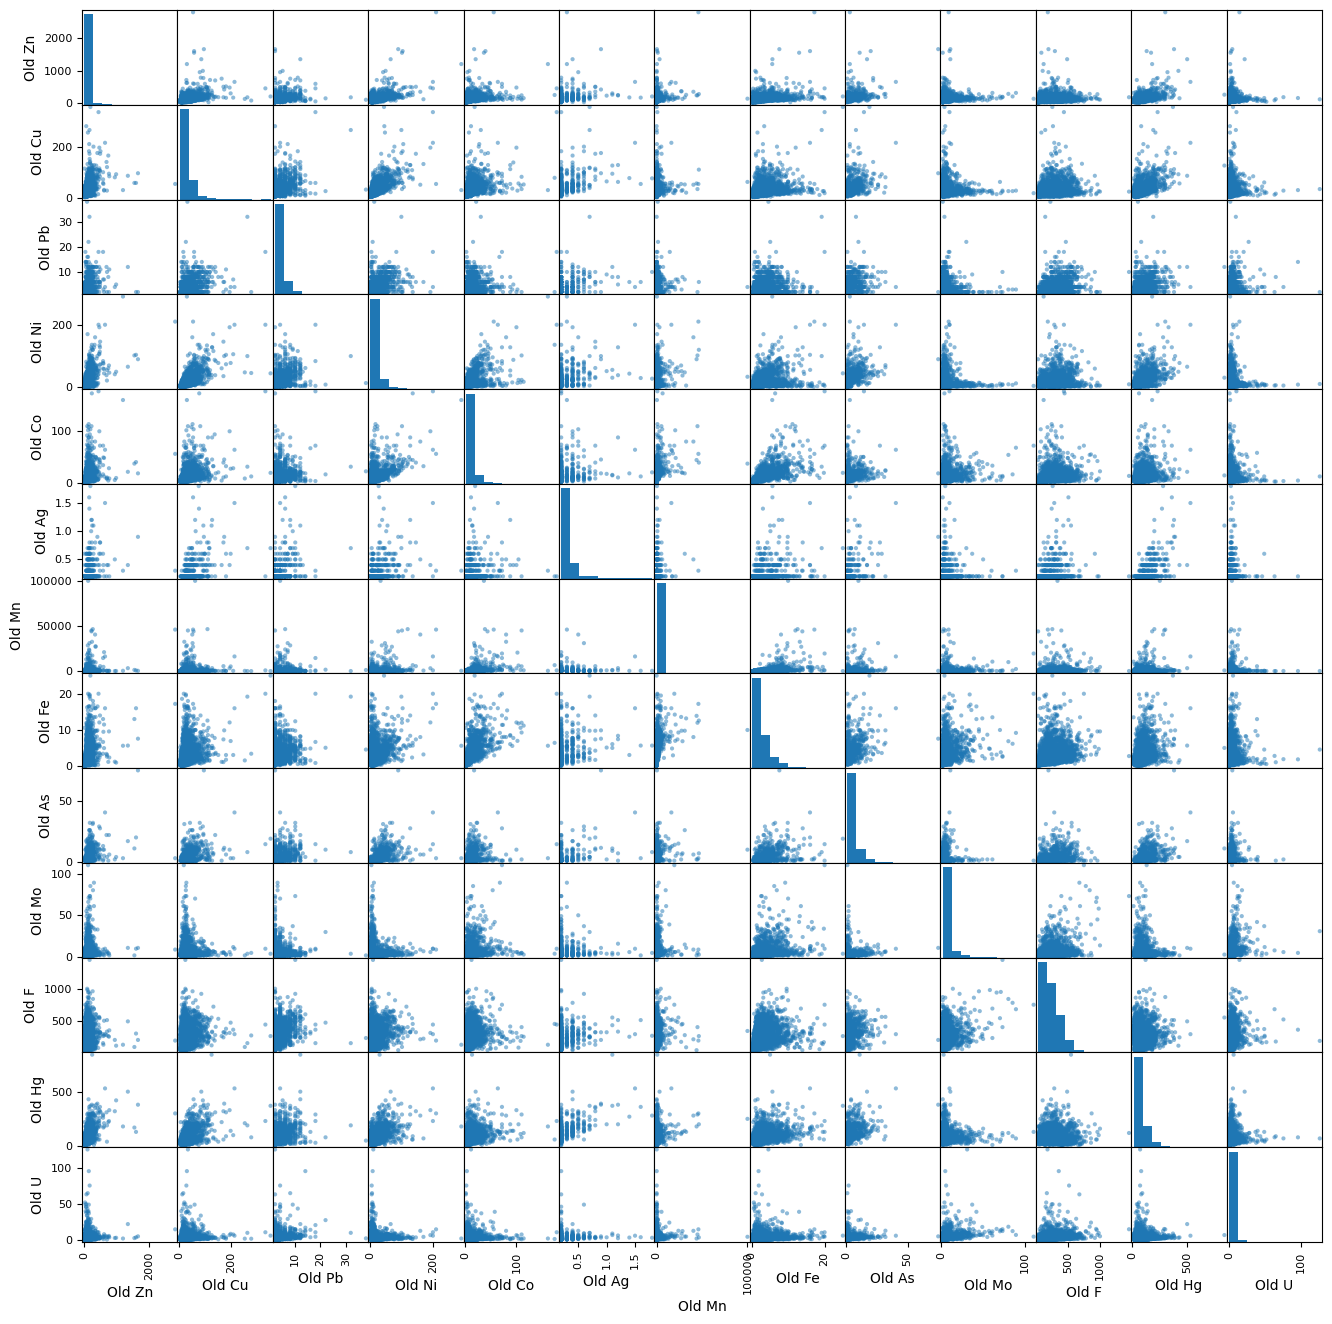

In [112]:
# We are not going to get into depths about how plotting works and ways to visualize.
# but let's check the fruits of our labour

pd.plotting.scatter_matrix(df_merged[new_df1_elements], figsize = (16,16))
plt.show()

In [113]:
# We'll export the processed data to be used later.

df_merged.to_csv('Merged_Chem.csv')